# Predictions: Heart Diseases

Prediction of heart disease given medical informartion. 

## Libraries

In [1]:
from pprint import pprint

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

pd.set_option('display.max_colwidth', None)

In [2]:
MAX_DATASET_SAMPLES = 5000 # Datasets will the capped to this sample_size to keep experiments fast 

## Import Data

In [3]:
datasets = [
    {
        "name": "Mobile Health Human Behavior Analysis",
        "path": "data/mhealth_raw_data.csv",
        # "path_train": "data/",
        # "path_test": "data/",
        "features_numerical": [], # [ All of them, except subject and Activity ]
        "features_categorical": [],
        "target": "Activity",
    },

    {
        "name": "Human Activity Recognition Trondheim (HARTH)",
        # "path": #,
        "path_train": "data/har_trondheim/train.csv",
        "path_test": "data/har_trondheim/test.csv",
        "features_numerical": [], # [ All of them, except Activity ]
        "features_categorical": [],
        "target": "Activity",
    },

    {
        "name": "Human Activity Recognition with Smartphones",
        # "path": #,
        "path_train": "data/har_with_smartphones/train.csv",
        "path_test": "data/har_with_smartphones/test.csv",
        "features_numerical": [], # [ All of them, except subject and Activity ]
        "features_categorical": [],
        "target": "Activity",
    },
]

for dataset in datasets: 
    file_path = dataset["path"] if "path" in dataset else dataset["path_train"]
    columns = pd.read_csv(file_path, nrows=0).columns.tolist()
    dataset["features_numerical"] = [f for f in columns if f not in ("subject", dataset["target"])]

pprint(datasets) 

[{'features_categorical': [],
  'features_numerical': ['alx',
                         'aly',
                         'alz',
                         'glx',
                         'gly',
                         'glz',
                         'arx',
                         'ary',
                         'arz',
                         'grx',
                         'gry',
                         'grz'],
  'name': 'Mobile Health Human Behavior Analysis',
  'path': 'data/mhealth_raw_data.csv',
  'target': 'Activity'},
 {'features_categorical': [],
  'features_numerical': ['Feature_1',
                         'Feature_2',
                         'Feature_3',
                         'Feature_4',
                         'Feature_5',
                         'Feature_6'],
  'name': 'Human Activity Recognition Trondheim (HARTH)',
  'path_test': 'data/har_trondheim/test.csv',
  'path_train': 'data/har_trondheim/train.csv',
  'target': 'Activity'},
 {'features_categorical': [],
  'f

In [4]:
dataset_path = datasets[0]["path"]
df = pd.read_csv(dataset_path)
df

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.449020,-1.01030,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.449020,-1.01030,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.449020,-1.01030,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.456860,-1.00820,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.456860,-1.00820,0.025862,0,subject1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215740,1.7849,-9.8287,0.29725,-0.341370,-0.90056,-0.61493,-3.7198,-8.9071,0.294230,0.041176,-0.99384,-0.480600,0,subject10
1215741,1.8687,-9.8766,0.46236,-0.341370,-0.90056,-0.61493,-3.7160,-8.7455,0.448140,0.041176,-0.99384,-0.480600,0,subject10
1215742,1.6928,-9.9290,0.16631,-0.341370,-0.90056,-0.61493,-3.8824,-9.1155,0.450480,0.041176,-0.99384,-0.480600,0,subject10
1215743,1.5279,-9.6306,0.30458,-0.341370,-0.90056,-0.61493,-3.5564,-9.1441,0.594880,0.041176,-0.99384,-0.480600,0,subject10


## EDA

In [5]:
def describe_dataframe(df:pd.DataFrame)->pd.DataFrame:
    df_describe = df.describe()
    df_describe.loc['dtype'] = df_describe.dtypes
    df_describe.loc['null_count'] = df_describe.isnull().sum()
    print("df.shape:", df.shape)
    return df_describe

describe_dataframe(df)

df.shape: (1215745, 14)


,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity
count,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0,1215745.0
mean,1.4942,-9.692878,-0.954806,-0.001599,-0.616632,-0.158781,-3.713413,-5.805526,2.39388,-0.276106,-0.466434,0.266633,1.741465
std,3.826485,4.171303,5.461803,0.491217,0.354641,0.546798,4.763586,5.757639,3.876503,0.527689,0.555551,0.56438,3.283679
min,-22.146,-19.619,-19.373,-2.1466,-7.7899,-2.6267,-22.361,-18.972,-18.239,-8.3392,-3.5708,-2.6897,0.0
25%,0.14131,-10.201,-2.6494,-0.43599,-0.81801,-0.59332,-6.076,-9.4042,0.12965,-0.70588,-0.89733,-0.23707,0.0
50%,1.3089,-9.6703,-0.016456,-0.014842,-0.70732,-0.19057,-2.9776,-7.4615,1.9281,-0.3549,-0.6345,0.30172,0.0
75%,2.5758,-9.0422,1.3013,0.44898,-0.54034,0.3222,-1.1937,-2.5339,4.9147,0.096078,-0.10678,0.77802,2.0
max,20.054,21.161,25.015,60.484,2.0113,2.7701,19.864,22.191,25.741,3.3196,1.5565,2.75,12.0
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
null_count,0,0,0,0,0,0,0,0,0,0,0,0,0


## Define Model

In [6]:
# Suppress onehot transformation warnings
# import warnings
# import re
# original_showwarning = warnings.showwarning
# def custom_showwarning(message, category, filename, lineno, file=None, line=None):
#     if re.match(r"Found unknown categories in columns \[\d+\] during transform\. These unknown categories will be encoded as all zeros", str(message)):
#         return  # Suppress the specific warning
#     original_showwarning(message, category, filename, lineno, file, line)
# warnings.showwarning = custom_showwarning

In [7]:
from sklearn import set_config

# Increase the diagram rendering size
set_config(display='diagram')  # Ensure the pipeline is displayed as a diagram
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (20, 8)  # Adjust the size as needed

In [8]:
from sklearn.base import BaseEstimator
from sklearn.ensemble import RandomForestClassifier

def create_pipeline(dataset:dict, classifier:BaseEstimator)->Pipeline:

    features_numerical = dataset["features_numerical"]
    features_categorical = dataset["features_categorical"]
    target = dataset['target']
    features_all = features_numerical+features_categorical

    numerical_pipeline = Pipeline(steps=[
        # ('impute', SimpleImputer(strategy='mean')),
        ('scale', StandardScaler())
    ])
    categorical_pipeline = Pipeline(steps=[
        # ('impute', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
    ])
    column_transformer = ColumnTransformer(transformers=[
        ('numerical', numerical_pipeline, features_numerical),
        ('categorical', categorical_pipeline, features_categorical)
    ])
    pipeline = Pipeline(steps=[
        ('preprocessor', column_transformer),
        ('classifier', classifier)
    ])
    
    return pipeline

# pipeline example
create_pipeline(datasets[0], RandomForestClassifier())

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['alx', 'aly', 'alz', 'glx',
                                                   'gly', 'glz', 'arx', 'ary',
                                                   'arz', 'grx', 'gry',
                                                   'grz']),
                                                 ('categorical',
                                                  Pipeline(steps=[('one_hot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  [])])),
                ('classifier', RandomForestClassifier())])

In [9]:
from sklearn.base import BaseEstimator
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier


classifiers = [
    # SVC(probability=True),
    KNeighborsClassifier(),
    LogisticRegression(n_jobs=-1),
    # MLPClassifier(max_iter=1000),
    # RandomForestClassifier(n_jobs=-1),
    # ExtraTreesClassifier(n_jobs=-1),
    # GradientBoostingClassifier(),
    # paper
    # StackingClassifier(n_jobs=-1, estimators=[('lr', LogisticRegression(n_jobs=-1)),    ('rf', RandomForestClassifier(n_jobs=-1))], final_estimator=LogisticRegression()),
    # StackingClassifier(n_jobs=-1, estimators=[('svm', SVC(probability=True)),           ('mlp', MLPClassifier(max_iter=1000))], final_estimator=LogisticRegression()),
    # StackingClassifier(n_jobs=-1, estimators=[('lr', LogisticRegression(n_jobs=-1)),    ('mlp', MLPClassifier(max_iter=1000))], final_estimator=LogisticRegression()),
    # # Arpitha
    # StackingClassifier(n_jobs=-1, estimators=[('knn', KNeighborsClassifier(n_jobs=-1)), ('gb', GradientBoostingClassifier())], final_estimator=LogisticRegression()),
    # StackingClassifier(n_jobs=-1, estimators=[('lr', LogisticRegression(n_jobs=-1)), ('gb', GradientBoostingClassifier())], final_estimator=LogisticRegression()),
    # StackingClassifier(n_jobs=-1, estimators=[('lr', LogisticRegression(n_jobs=-1)), ('knn', KNeighborsClassifier(n_jobs=-1))], final_estimator=LogisticRegression()),

]

In [10]:
create_pipeline(datasets[0], StackingClassifier(n_jobs=-1, estimators=[('lr', LogisticRegression(n_jobs=-1)), ('gb', GradientBoostingClassifier())], final_estimator=LogisticRegression()))

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['alx', 'aly', 'alz', 'glx',
                                                   'gly', 'glz', 'arx', 'ary',
                                                   'arz', 'grx', 'gry',
                                                   'grz']),
                                                 ('categorical',
                                                  Pipeline(steps=[('one_hot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  [])])),
                ('classifier',
                 StackingClassifier(estimators=[('lr',
                                                 LogisticRegression(n_jobs=-1)),
                                                ('gb',
                                                 GradientBoostingClassifier())],
                                    final_estimator=LogisticRegression(),
                                    n_jobs=-1))])

## Training

In [11]:
results = {}

for dataset in datasets:
    print(40*"##")
    print("Dataset:", dataset["name"])
    dataset_name = dataset["name"]
    results[dataset_name] = {}
    # Load Data
    if "path" in dataset:
        df = pd.read_csv(dataset['path'])
    elif "path_train" in dataset:
        df = pd.read_csv(dataset['path_train'])
    else: 
        raise("Missing path")
    
    # Subsample Data
    if len(df)>MAX_DATASET_SAMPLES: # Use subsample if the data is too large
        df = df.sample(n=MAX_DATASET_SAMPLES, replace=False, random_state=42)

    for classifier in classifiers:
        classifier_name = str(classifier)
        results[dataset_name][classifier_name] = {}
        
        # Crossvalidation
        accuracies = []
        f1_scores = []
        auc_scores = []
        for i in range(10):
            features_numerical = dataset["features_numerical"]
            features_categorical = dataset["features_categorical"]
            target = dataset['target']
            features_all = features_numerical+features_categorical

            # Data Split
            df_train, df_val = train_test_split(df, test_size=0.2)
            X_train = df_train[features_all]
            Y_train = df_train[target]
            X_val = df_val[features_all]
            Y_val = df_val[target]

            # Create pipeline
            pipeline = create_pipeline(dataset, classifier)
            
            # Train and predict
            pipeline.fit(X_train, Y_train)
            y_pred_val = pipeline.predict(X_val)
            # y_prob_val = pipeline.predict_proba(X_val)[:, 1]

            # Metrics
            accuracies.append(accuracy_score(Y_val, y_pred_val))
            # auc_scores.append(roc_auc_score(Y_val, y_prob_val, multi_class="ovo"))
            f1_scores.append(f1_score(Y_val, y_pred_val, average='weighted'))

        accuracy = np.average(accuracies)
        results[dataset_name][classifier_name]["accuracy"] = accuracy
        print(classifier, "average acc:", accuracy)

        f1 = np.average(f1_scores)
        results[dataset_name][classifier_name]["f1"] = f1
        print(classifier, "average f1:", f1)

        # auc = np.average(auc_scores)
        # results[dataset_name][classifier_name]["auc"] = auc
        # print(classifier, "average auc:", auc)

# pprint(results)

################################################################################
Dataset: Mobile Health Human Behavior Analysis
KNeighborsClassifier() average acc: 0.7723000000000001
KNeighborsClassifier() average f1: 0.7615602759708601
LogisticRegression(n_jobs=-1) average acc: 0.7358999999999999
LogisticRegression(n_jobs=-1) average f1: 0.6536457158611622
################################################################################
Dataset: Human Activity Recognition Trondheim (HARTH)
KNeighborsClassifier() average acc: 0.8136999999999999
KNeighborsClassifier() average f1: 0.7959700879476413
LogisticRegression(n_jobs=-1) average acc: 0.6573
LogisticRegression(n_jobs=-1) average f1: 0.5825477074015328
################################################################################
Dataset: Human Activity Recognition with Smartphones
KNeighborsClassifier() average acc: 0.9495999999999999
KNeighborsClassifier() average f1: 0.9492135570267756
LogisticRegression(n_jobs=-1) average acc:

In [12]:
results

{'Mobile Health Human Behavior Analysis': {'KNeighborsClassifier()': {'accuracy': np.float64(0.7723000000000001),
   'f1': np.float64(0.7615602759708601)},
  'LogisticRegression(n_jobs=-1)': {'accuracy': np.float64(0.7358999999999999),
   'f1': np.float64(0.6536457158611622)}},
 'Human Activity Recognition Trondheim (HARTH)': {'KNeighborsClassifier()': {'accuracy': np.float64(0.8136999999999999),
   'f1': np.float64(0.7959700879476413)},
  'LogisticRegression(n_jobs=-1)': {'accuracy': np.float64(0.6573),
   'f1': np.float64(0.5825477074015328)}},
 'Human Activity Recognition with Smartphones': {'KNeighborsClassifier()': {'accuracy': np.float64(0.9495999999999999),
   'f1': np.float64(0.9492135570267756)},
  'LogisticRegression(n_jobs=-1)': {'accuracy': np.float64(0.9788),
   'f1': np.float64(0.9787826600022129)}}}

In [13]:
def format_results(results_dict:dict)->pd.DataFrame:
    """
    NOTE: Docstring created with ChatGPT, edited by a human
    Converts a nested dictionary of results into a DataFrame with Multi-Index columns.
    
    Parameters:
    - results_dict (dict): Nested dictionary where the first level keys are datasets, 
      the second level keys are models, and the leaf values are dictionaries of metrics.
      
    Returns:
    - pd.DataFrame: A DataFrame with Multi-Index columns for datasets and models, 
      and rows for metrics.
    """
    results_df = pd.DataFrame.from_dict(
        {(dataset, model): metrics for dataset, model_dict in results_dict.items() for model, metrics in model_dict.items()},
        orient="index",
    )

    # Set MultiIndex for the columns
    results_df.index = pd.MultiIndex.from_tuples(results_df.index, names=["Dataset", "Model"])
    results_df.index = results_df.index.swaplevel("Dataset", "Model")
    results_df = results_df.sort_index(level=["Model", "Dataset"])
    results_df.columns.name = "Metric"

    return results_df

display(format_results(results))


Metric                                                                      accuracy  \
Model                         Dataset                                                  
KNeighborsClassifier()        Human Activity Recognition Trondheim (HARTH)    0.8137   
                              Human Activity Recognition with Smartphones     0.9496   
                              Mobile Health Human Behavior Analysis           0.7723   
LogisticRegression(n_jobs=-1) Human Activity Recognition Trondheim (HARTH)    0.6573   
                              Human Activity Recognition with Smartphones     0.9788   
                              Mobile Health Human Behavior Analysis           0.7359   

Metric                                                                            f1  
Model                         Dataset                                                 
KNeighborsClassifier()        Human Activity Recognition Trondheim (HARTH)  0.795970  
                              Human Activity Recognition with Smartphones   0.949214  
                              Mobile Health Human Behavior Analysis         0.761560  
LogisticRegression(n_jobs=-1) Human Activity Recognition Trondheim (HARTH)  0.582548  
                              Human Activity Recognition with Smartphones   0.978783  
                              Mobile Health Human Behavior Analysis         0.653646

In [21]:
def average_metrics(results):
    # Initialize a dictionary to store metrics by model
    averaged_results = {}
    
    # Iterate through datasets and collect metrics for each model
    for models in results.values():
        for model, metrics in models.items():
            if model not in averaged_results:
                averaged_results[model] = {'accuracy': [], 'f1': [], 'auc': []}
            for metric, value in metrics.items():
                averaged_results[model][metric].append(value)
    
    # Calculate averages for each model
    for model, metrics in averaged_results.items():
        averaged_results[model] = {metric: np.mean(values) for metric, values in metrics.items()}
    
    # Convert the averaged results into a DataFrame
    df = pd.DataFrame.from_dict(averaged_results, orient='index')
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'Model'}, inplace=True)
    
    return df

average_metrics(results)

c:\Users\AsusTUF\anaconda3\envs\tru_HAR\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\AsusTUF\anaconda3\envs\tru_HAR\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,Model,accuracy,f1,auc
0,KNeighborsClassifier(),0.845200,0.835581,NaN
1,LogisticRegression(n_jobs=-1),0.790667,0.738325,NaN


In [22]:
import json

# Serializing json
json_object = json.dumps(results, indent=4)
 
# Writing to sample.json
with open("results.json", "w") as outfile:
    outfile.write(json_object)

## Graphs

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

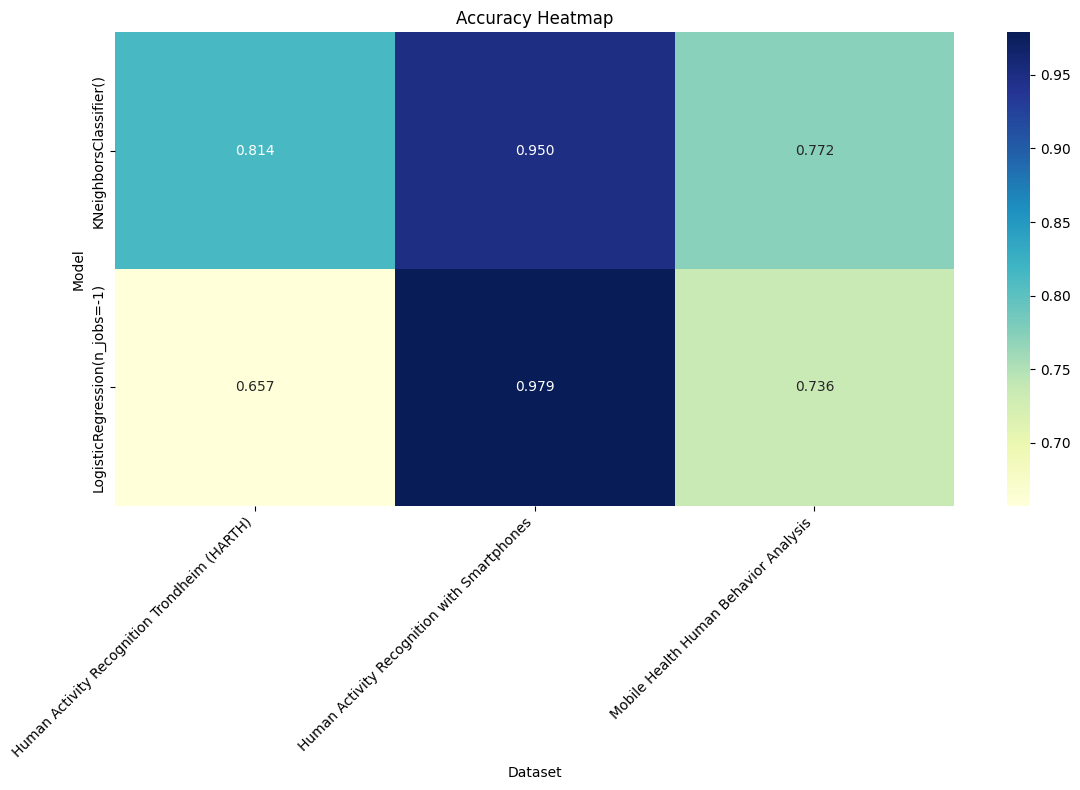

In [24]:
def heatmap_results(results):
    # Create a DataFrame from the dictionary
    data = []
    for dataset, models in results.items():
        for model, metrics in models.items():
            data.append({'Dataset': dataset, 'Model': model, **metrics})
    
    df = pd.DataFrame(data)
    metrics = ['accuracy']# , 'f1', 'auc']
    
    for metric in metrics:
        pivot_table = df.pivot(index='Model', columns='Dataset', values=metric)
        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="YlGnBu")
        plt.title(f'{metric.capitalize()} Heatmap')
        plt.ylabel('Model')
        plt.xlabel('Dataset')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

heatmap_results(results)

c:\Users\AsusTUF\anaconda3\envs\tru_HAR\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\AsusTUF\anaconda3\envs\tru_HAR\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<Figure size 1000x600 with 0 Axes>

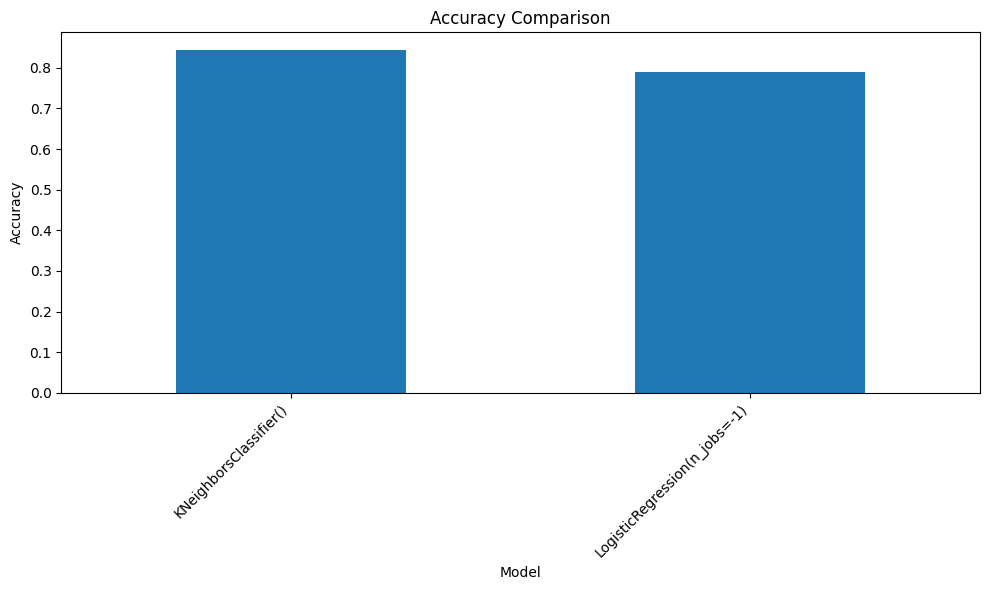

<Figure size 1000x600 with 0 Axes>

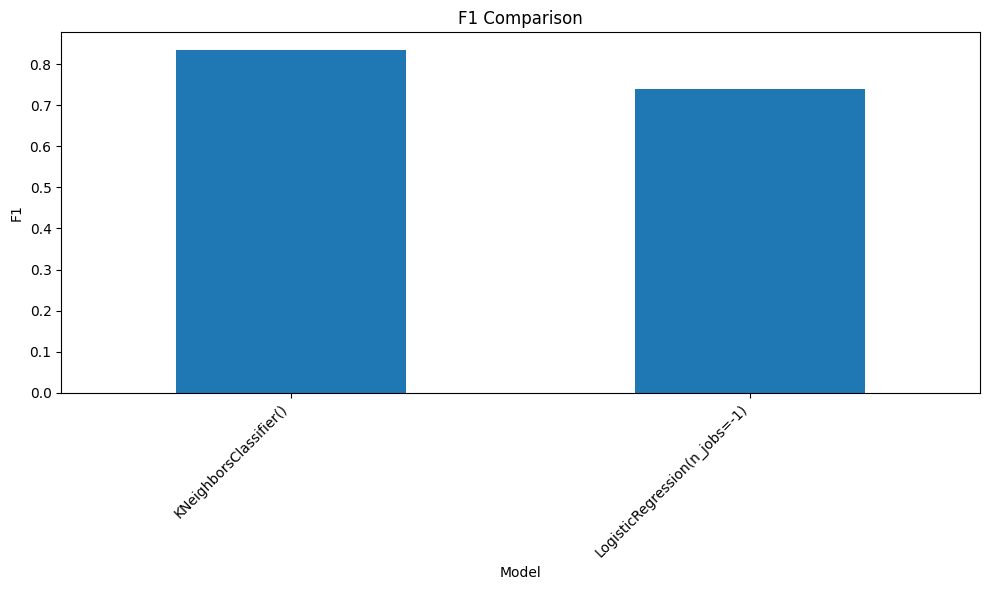

<Figure size 1000x600 with 0 Axes>

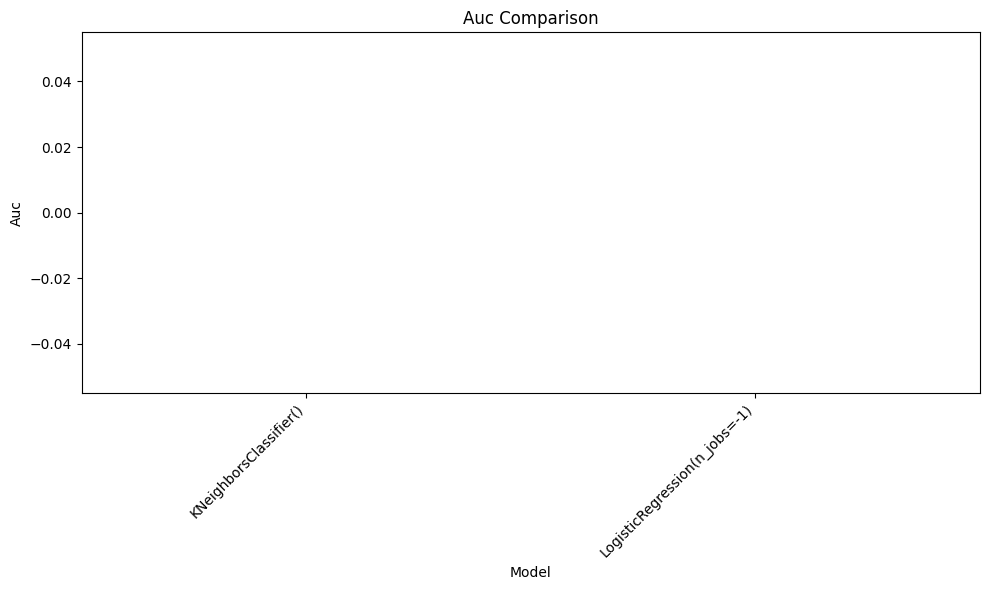

In [25]:
def bar_chart_results(results):
    df = average_metrics(results)
    metrics = ['accuracy', 'f1', 'auc']
    
    for metric in metrics:
        plt.figure(figsize=(10, 6))
        df.sort_values(by=metric, ascending=False).plot(
            x='Model', y=metric, kind='bar', legend=False, figsize=(10, 6), title=f'{metric.capitalize()} Comparison'
        )
        plt.ylabel(metric.capitalize())
        plt.xlabel('Model')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

bar_chart_results(results)


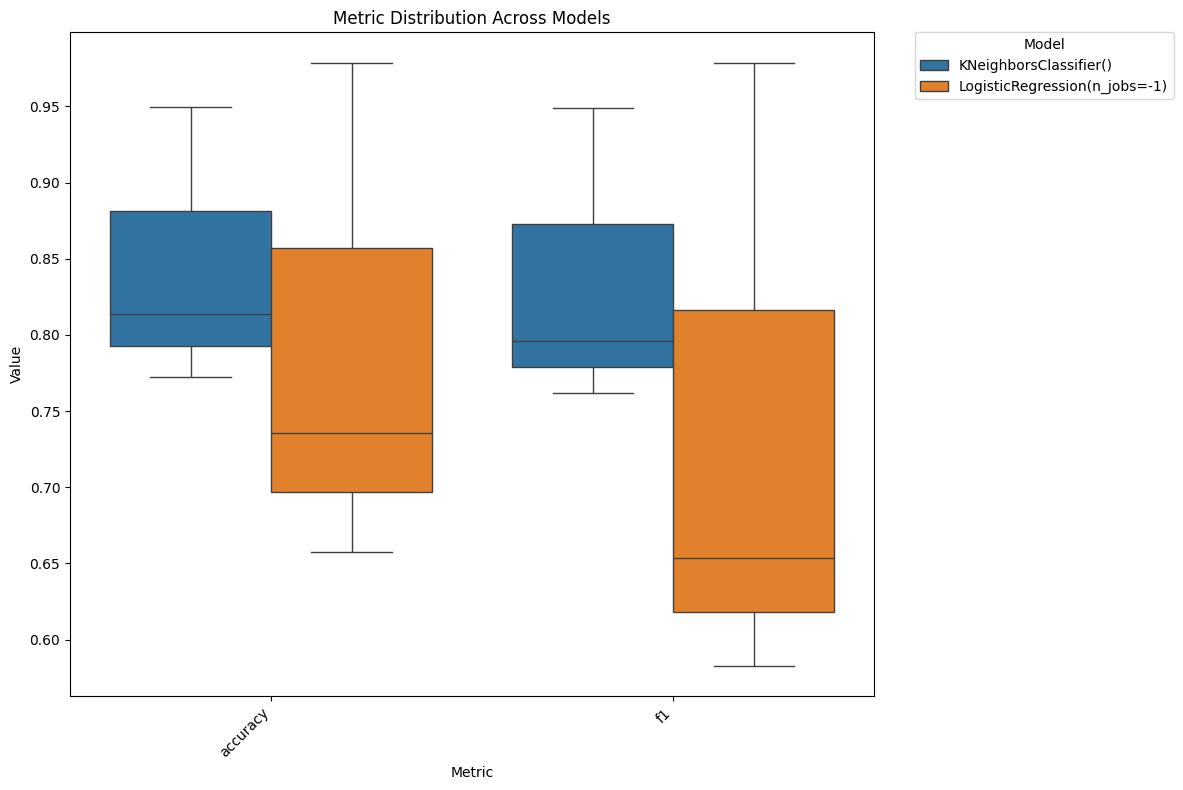

In [26]:
def box_plot_results(results):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    
    # Create a DataFrame from the dictionary
    data = []
    for dataset, models in results.items():
        for model, metrics in models.items():
            for metric, value in metrics.items():
                data.append({'Metric': metric, 'Value': value, 'Model': model, 'Dataset': dataset})
    
    df = pd.DataFrame(data)
    
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='Metric', y='Value', hue='Model', data=df)
    plt.title('Metric Distribution Across Models')
    plt.ylabel('Value')
    plt.xlabel('Metric')
    plt.xticks(rotation=45, ha='right')
    # Move legend outside
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

box_plot_results(results)

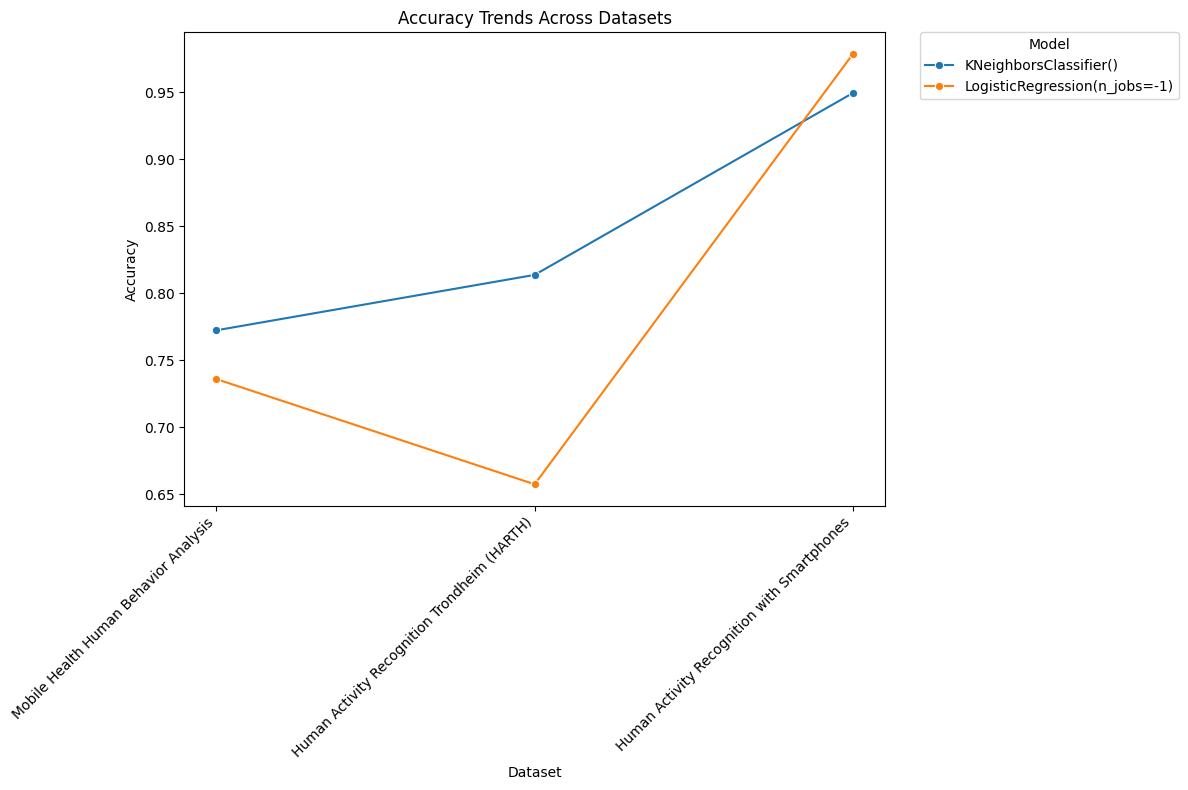

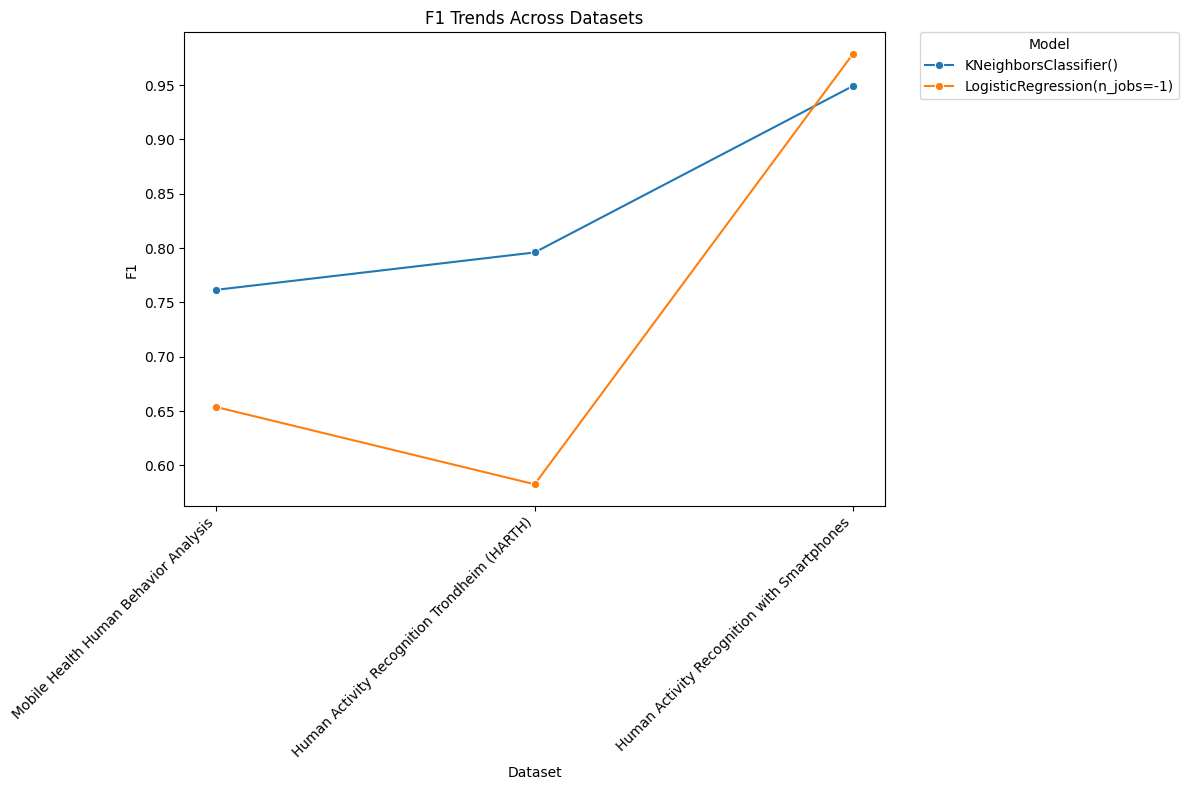

C:\Users\AsusTUF\AppData\Local\Temp\ipykernel_27568\2764278313.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


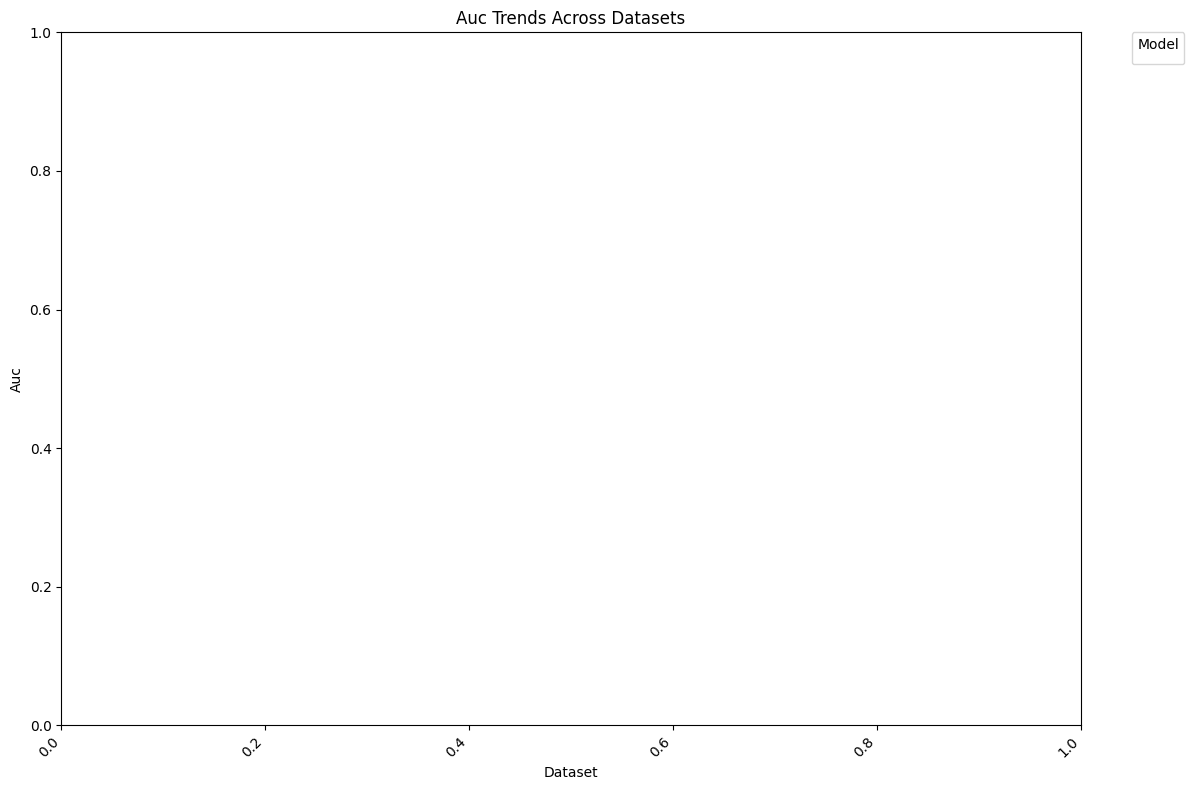

In [27]:
def line_chart_results(results):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    
    # Create a DataFrame from the dictionary
    data = []
    for dataset, models in results.items():
        for model, metrics in models.items():
            for metric, value in metrics.items():
                data.append({'Dataset': dataset, 'Metric': metric, 'Value': value, 'Model': model})
    
    df = pd.DataFrame(data)
    metrics = ['accuracy', 'f1', 'auc']
    
    for metric in metrics:
        plt.figure(figsize=(12, 8))
        sns.lineplot(x='Dataset', y='Value', hue='Model', data=df[df['Metric'] == metric], marker='o')
        plt.title(f'{metric.capitalize()} Trends Across Datasets')
        plt.ylabel(metric.capitalize())
        plt.xlabel('Dataset')
        plt.xticks(rotation=45, ha='right')
        # Move legend outside
        plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.tight_layout()
        plt.show()

line_chart_results(results)